# Distances, Paths, Centrality

In this lab, we will ask questions around the notion of 'distance' betweeh the vertices in a graph.
We will also see which vertices are close to the 'center' of the graph, which are far removed, and apply these notions to both graphs and trees.

In [1]:
from lab5_helpers import *

In [16]:
# Let's start with a small tree as a motivating example
T = build_graph(sample_tree_edges())
graph_summary(T)

{'number_of_nodes': 7,
 'number_of_edges': 6,
 'connected': True,
 'is_tree': True,
 'degree_dict': {'A': 1, 'B': 2, 'C': 3, 'D': 2, 'E': 1, 'F': 2, 'G': 1}}

We can choose two vertices and compute the shortest path between them. Let's use vertices A and E.

In [3]:
shortest_path_between(T, "A", "E")

['A', 'B', 'C', 'D', 'E']

In [4]:
distance_between(T, "A", "E")

4

The path between A and E is shown in the first list, and traverses $A \rightarrow B \rightarrow C \rightarrow D \rightarrow E$. This path touches five vertices through 4 edges, so the distance from A to E is 4.

In [5]:
# TODO
# Which pair you tested was farther apart?
# Can two vertices have more than one shortest path in this tree?
# Why or why not?
# Which vertices seem visually close to the “middle”?

### Part 2: Centrality

We want to some up with a metric that indicates how close to the 'center' of the graph a particular vertex is. First, we will compute the distances between all the vertices in the graph.

In [3]:
all_pairs_distances(T)

{'A': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'F': 3, 'E': 4, 'G': 4},
 'B': {'B': 0, 'A': 1, 'C': 1, 'D': 2, 'F': 2, 'E': 3, 'G': 3},
 'C': {'C': 0, 'B': 1, 'D': 1, 'F': 1, 'A': 2, 'E': 2, 'G': 2},
 'D': {'D': 0, 'C': 1, 'E': 1, 'B': 2, 'F': 2, 'A': 3, 'G': 3},
 'E': {'E': 0, 'D': 1, 'C': 2, 'B': 3, 'F': 3, 'A': 4, 'G': 4},
 'F': {'F': 0, 'C': 1, 'G': 1, 'B': 2, 'D': 2, 'A': 3, 'E': 3},
 'G': {'G': 0, 'F': 1, 'C': 2, 'B': 3, 'D': 3, 'A': 4, 'E': 4}}

The output above is a dictionary of dictionaries: the first key is the vertex, where the value is a second dictionary with a key for every vertex and a value for the distance. One thing we can do is convert this into a *matrix* that encodes this information. These matrices are easily consumable by a variety of algorithms we will see later in the course.

In [4]:
dist_mat = distance_matrix(T)
dist_mat

Vertices: ['A', 'B', 'C', 'D', 'E', 'F', 'G']


array([[0., 1., 2., 3., 4., 3., 4.],
       [1., 0., 1., 2., 3., 2., 3.],
       [2., 1., 0., 1., 2., 1., 2.],
       [3., 2., 1., 0., 1., 2., 3.],
       [4., 3., 2., 1., 0., 3., 4.],
       [3., 2., 1., 2., 3., 0., 1.],
       [4., 3., 2., 3., 4., 1., 0.]])

Notice that the diagonal of the matrix is all zeros, and that the values are reflected over this diagonal. This is true for an *undirected* graph, like all the examples we have seen so far, but is not true for *directed* graphs we will see later in the course.

We can then measure properties of the graph, such as the eccentricity, the radius, the diameter, the center, and find periphery vertices.

In [5]:
eccentricity_dict(T)

{'A': 4, 'B': 3, 'C': 2, 'D': 3, 'E': 4, 'F': 3, 'G': 4}

In [6]:
gr = graph_radius(T)
gd = graph_diameter(T)
print(f"Radius: {gr}, diameter: {gd}")

Radius: 2, diameter: 4


In [7]:
graph_center(T)

['C']

In [8]:
graph_periphery(T)

['A', 'E', 'G']

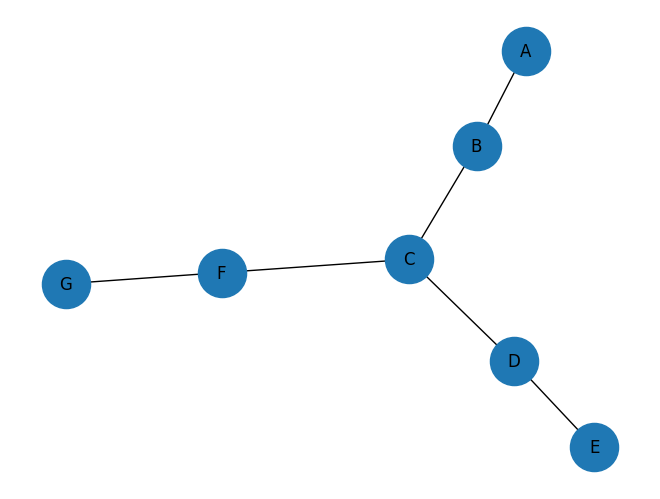

In [9]:
draw_graph(T)

We can see from the graph visualization that C is the central vertex of the graph, and A, E, G the leaves. We also see this agrees with the eccentricity: vertices A, E, G have the largest eccentricity, and vertex C has the lowest.

### Part 3: Changing the graph geometry

Let's see how much adding a single edge can change the measures we computed above.

In [17]:
G = build_graph(sample_modified_edges())
graph_summary(G)

{'number_of_nodes': 7,
 'number_of_edges': 7,
 'connected': True,
 'is_tree': False,
 'degree_dict': {'A': 2, 'B': 2, 'C': 3, 'D': 2, 'E': 2, 'F': 2, 'G': 1}}

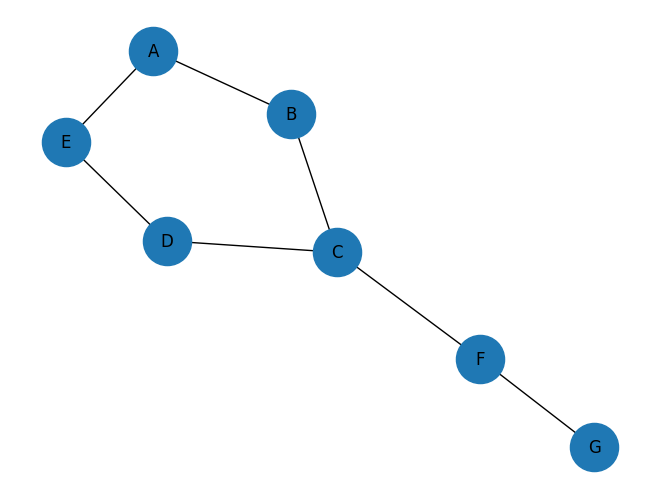

In [12]:
draw_graph(G)

In [14]:
print('Original tree eccentricity: \n')
print(eccentricity_dict(T))
print('New graph eccentricity: \n')
print(eccentricity_dict(G))

Original tree eccentricity: 

{'A': 4, 'B': 3, 'C': 2, 'D': 3, 'E': 4, 'F': 3, 'G': 4}
New graph eccentricity: 

{'A': 4, 'B': 3, 'C': 2, 'D': 3, 'E': 4, 'F': 3, 'G': 4}


In [18]:
print("Tree diameter:", graph_diameter(T))
print("Modified graph diameter:", graph_diameter(G))

print("Tree radius:", graph_radius(T))
print("Modified graph radius:", graph_radius(G))

print("Tree center:", graph_center(T))
print("Modified graph center:", graph_center(G))

Tree diameter: 4
Modified graph diameter: 4
Tree radius: 2
Modified graph radius: 2
Tree center: ['C']
Modified graph center: ['C']


In [19]:
# TODO:

# What happened here? Explain your findings, then experiment with adding and removing edges of the tree.

### Pat 4: varying tree structures

We can also look at trees that have very different geometric structures.

In [2]:
P = generate_path_graph(8)
S = generate_star_graph(8)
R = generate_random_tree(8, seed=8)

In [3]:
print("Path graph diameter:", graph_diameter(P), "radius:", graph_radius(P), "center:", graph_center(P))
print("Star graph diameter:", graph_diameter(S), "radius:", graph_radius(S), "center:", graph_center(S))
print("Random tree diameter:", graph_diameter(R), "radius:", graph_radius(R), "center:", graph_center(R))

Path graph diameter: 7 radius: 4 center: [3, 4]
Star graph diameter: 2 radius: 1 center: [0]
Random tree diameter: 6 radius: 3 center: [2]


In [4]:
# TODO
# Which tree has the largest diameter?
# Which tree has the smallest radius?
# Which tree feels most “spread out”?
# Which tree feels most “centralized”?
# What does the star graph teach you about center?
# What does the path graph teach you about diameter?

### Part 5: Random exploration

Look at some patterns in random tree generation. Modify the code as you see fit to probe for patterns and develop some conjectures.

In [ ]:
for n in [6, 8, 10, 12]:
    Tn = generate_random_tree(n, seed=n)
    print(
        "n =", n,
        "| diameter =", graph_diameter(Tn),
        "| radius =", graph_radius(Tn),
        "| center =", graph_center(Tn),
        "| periphery =", graph_periphery(Tn),
    )

In [5]:
# TODO
# Does the center always have one vertex?
# Can a tree have two central vertices?
# What kind of tree seems to have the largest diameter?
# What kind of tree seems to have the smallest diameter?

## Reflection and Conjectures

Based on your experiments, respond to the following.

1. What does the diameter measure in a graph?
2. What does the radius measure?
3. What does it mean for a vertex to be in the center?
4. How did adding one edge change the graph’s geometry?
5. Which type of tree seems to maximize distance?
6. Which type of tree seems to minimize distance?
7. State one conjecture about centers of trees.
8. State one conjecture about how adding edges affects diameter.
9. Which of your observations feel like they should be provable?